
# Redes Neuronales Convolucionales (CNN) con PyTorch

Este laboratorio está adaptado del curso [Microsoft AI for Beginners](https://github.com/microsoft/AI-For-Beginners), 
pero con explicaciones ampliadas y orientadas a estudiantes de nivel **máster en Ciencia de Datos**.

En esta sesión, construiremos y entrenaremos una **red neuronal convolucional (CNN)** para clasificación de imágenes usando **PyTorch**.  
Discutiremos los fundamentos teóricos de las CNN, su arquitectura, y su rol en tareas de visión computacional moderna.


In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms


# Filtros Convolucionales

Los filtros convolucionales son pequeñas ventanas que se traslapan sobre la imagen y calculan un promedio sobre una vecindad de pixeles.

In [2]:
from torch.nn import functional as F

x = torch.randn(16, 3, 32, 32) # batch_size, channels, height, width
w = torch.randn(64, 3, 5, 5) # out_channels, in_channels, kernel_height, kernel_width
F.conv2d(x, w, padding='same').shape # feature maps con padding 'same'

torch.Size([16, 64, 32, 32])

In [3]:
F.conv2d(x, w, padding='valid').shape # feature maps con padding 'valid'

torch.Size([16, 64, 28, 28])

In [4]:
F.conv2d(x, w, padding='valid',stride=2).shape # feature maps con padding 'valid' y stride 2

torch.Size([16, 64, 14, 14])

In [5]:
F.conv2d(x, w, padding=(4,2),stride=(2,1)).shape # feature maps con padding  y stride diferentes en cada dimensión

torch.Size([16, 64, 18, 32])


## 1. Preparación y carga de datos

En visión por computador, la etapa de **preprocesamiento y normalización** de imágenes es crítica.
Trabajaremos con el conjunto **CIFAR-10**, que contiene 60,000 imágenes a color (32×32 píxeles) en 10 clases.

Cada imagen se normaliza a un rango `[-1, 1]` para estabilizar el entrenamiento de la red.


In [6]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)

classes = ('avión', 'auto', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión')


In [7]:
for images, labels in trainloader:
    break

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 32, 32])
torch.Size([32])


In [8]:
images.device

device(type='cpu')


## 2. Definición de la arquitectura de la CNN

La arquitectura propuesta sigue una estructura clásica similar a **LeNet-5**, compuesta por capas convolucionales, 
funciones de activación ReLU, y capas de agrupamiento (*pooling*) para la reducción espacial.

Esta estructura permite extraer **características jerárquicas**:  
- Las primeras capas capturan bordes y texturas.  
- Las capas profundas representan formas complejas y patrones semánticos.


In [9]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [10]:

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)      # 3 canales RGB -> 6 mapas de características
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net().to(device)


In [11]:
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)



## 3. Entrenamiento del modelo

El modelo se entrena mediante **propagación hacia atrás** (*backpropagation*), minimizando la **entropía cruzada** como función de pérdida.

Utilizaremos el optimizador **SGD (Stochastic Gradient Descent)** con **momentum**, lo que ayuda a estabilizar el gradiente y acelerar la convergencia.


In [25]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [12]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

loss_history = []
accuracy_history = []

for epoch in range(5):
    running_loss = 0.0
    for i, (inputs,labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loss_history.append(loss.item())
        _, predicted = torch.max(outputs, 1)
        correct = (predicted == labels).sum().item()
        accuracy = correct / labels.size(0)
        accuracy_history.append(accuracy)
        if i % 2000 == 1999:
            print(f'[Época {epoch + 1}, minibatch {i + 1}] pérdida: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Entrenamiento finalizado')


Entrenamiento finalizado


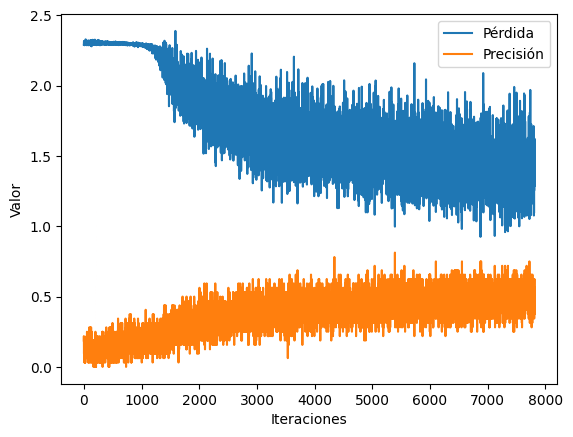

In [13]:
import matplotlib.pyplot as plt 

x_arr = list(range(len(loss_history)))
plt.plot(x_arr, loss_history, label='Pérdida')
plt.plot(x_arr, accuracy_history, label='Precisión')
plt.xlabel('Iteraciones')
plt.ylabel('Valor')
plt.legend()
plt.show()


## 4. Evaluación del desempeño

La evaluación se realiza midiendo la **precisión** sobre el conjunto de prueba.
En contextos de investigación, también se recomienda usar métricas adicionales como la matriz de confusión, F1-score o AUC.


In [15]:

correct = 0
total = 0
with torch.no_grad():
    for images,labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Precisión en el conjunto de prueba: {100 * correct / total:.2f}%')


Precisión en el conjunto de prueba: 50.04%



## 5. Reflexión final

Las **redes convolucionales** han transformado el campo de la visión por computador.  
Sin embargo, comprender su arquitectura requiere entender cómo cada capa contribuye a la representación jerárquica de las imágenes.

**Extensiones recomendadas para el laboratorio:**
- Implementar *Batch Normalization* y *Dropout* para mejorar la generalización.
- Visualizar mapas de activación intermedios.
- Reentrenar la red con un conjunto más complejo (por ejemplo, Tiny ImageNet).
